# Tutorial: Backend benchmarking and device deep-dive

This notebook studies a practical systems question: **when should we use convolution stencils vs edge-list message passing?**

Rather than relying on intuition, we run controlled benchmarks that separate two effects:

1. **End-to-end latency** for simulation, fitting, and forecasting.
2. **Operator-level throughput** for the raw spatial update under JIT.

We keep JIT enabled and report the active JAX backend so local CPU/GPU differences are explicit.

## What each key function does

- `compare_backends(...)`: runs a matched conv-vs-edges benchmark workflow.
- `make_grid_stencil(...)`: builds a dense local kernel for grid convolution.
- `make_grid_edgelist(...)`: builds a sparse adjacency for message passing.
- `apply_conv_stencil(...)` / `apply_edgelist(...)`: low-level spatial operators used inside model recurrences.

In [1]:
import time
NB_START = time.perf_counter()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from motac import (
    GridSpec,
    make_grid_stencil,
    make_grid_edgelist,
    apply_conv_stencil,
    apply_edgelist,
    compare_backends,
)

plt.style.use('seaborn-v0_8-whitegrid')

/home/oj/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
devices = jax.devices()
gpu_devices = [d for d in devices if d.platform == "gpu"]

print("Detected devices:", devices)
print("Default backend:", jax.default_backend())
print("JIT remains enabled unless JAX_DISABLE_JIT is explicitly set externally.")
if gpu_devices:
    print(f"GPU devices available: {len(gpu_devices)}")
else:
    print("No CUDA-enabled JAX backend detected for this run.")

Detected devices: [CpuDevice(id=0)]
Default backend: cpu
JIT remains enabled unless JAX_DISABLE_JIT is explicitly set externally.
No CUDA-enabled JAX backend detected for this run.


In [3]:
# Matched end-to-end benchmark under identical synthetic settings.
# compare_backends internally runs simulation -> MAP fit -> forecast for both backends.
results = compare_backends(
    grid_shape=(28, 28),
    time_steps=35,
    fit_steps=24,
    seed=11,
)

df = pd.DataFrame(
    [
        {
            "backend": r.backend,
            "simulation_seconds": r.simulation_seconds,
            "fit_seconds": r.fit_seconds,
            "forecast_seconds": r.forecast_seconds,
        }
        for r in results
    ]
)
df["total_seconds"] = df["simulation_seconds"] + df["fit_seconds"] + df["forecast_seconds"]

fastest = float(df["total_seconds"].min())
df["slowdown_vs_fastest"] = df["total_seconds"] / fastest

df.sort_values("total_seconds")

,backend,simulation_seconds,fit_seconds,forecast_seconds,total_seconds,slowdown_vs_fastest
1,edges,0.405041,0.509354,0.493587,1.407982,1.000000
0,conv,0.605985,1.829403,1.595210,4.030597,2.862676


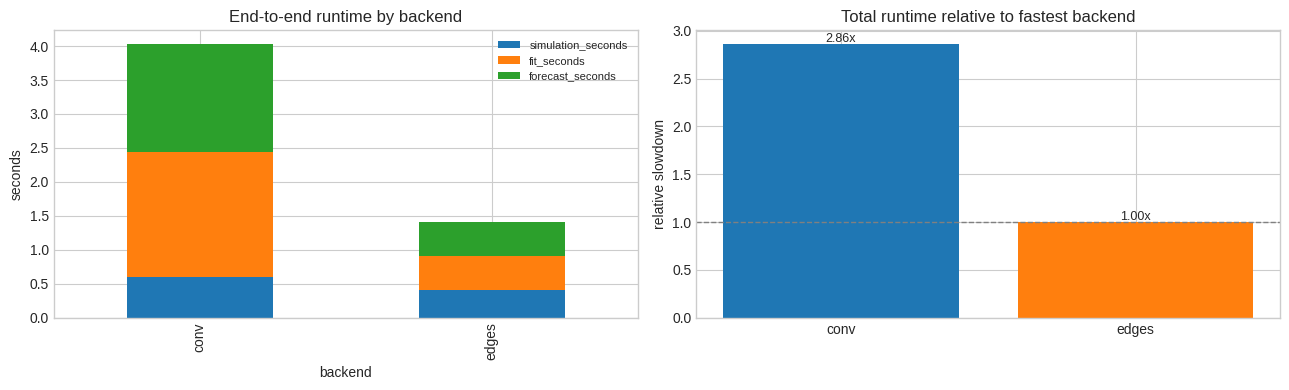

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plot_df = df.set_index("backend")[["simulation_seconds", "fit_seconds", "forecast_seconds"]]
plot_df.plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_ylabel("seconds")
axes[0].set_title("End-to-end runtime by backend")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].bar(df["backend"], df["slowdown_vs_fastest"], color=["tab:blue", "tab:orange"])
axes[1].axhline(1.0, linestyle="--", linewidth=1, color="gray")
axes[1].set_ylabel("relative slowdown")
axes[1].set_title("Total runtime relative to fastest backend")
for i, v in enumerate(df["slowdown_vs_fastest"]):
    axes[1].text(i, v + 0.02, f"{v:.2f}x", ha="center", fontsize=9)

plt.tight_layout()

## Operator-level timing and throughput interpretation

End-to-end benchmark differences combine many effects (simulation overhead, optimizer behavior, memory movement, and spatial operator cost). To isolate the pure backend kernel cost, we now benchmark just:

- `apply_conv_stencil(...)` on a `[H, W, C]` tensor,
- `apply_edgelist(...)` on a flattened `[J, C]` tensor.

Both paths are JIT-compiled and pre-warmed before timing.

In [5]:
h, w, c = 48, 48, 6
grid = GridSpec(shape=(h, w))
stencil = make_grid_stencil(kind="gaussian", size=5, sigma=1.2)
edges = make_grid_edgelist(grid, neighbourhood="moore")

x_grid = jax.random.normal(jax.random.PRNGKey(0), (h, w, c), dtype=jnp.float32)
x_flat = x_grid.reshape(h * w, c)

conv_fn = jax.jit(lambda arr: apply_conv_stencil(arr, stencil))
edge_fn = jax.jit(lambda arr: apply_edgelist(arr, edges))

# Warm-up so compile time does not contaminate throughput timings.
_ = conv_fn(x_grid).block_until_ready()
_ = edge_fn(x_flat).block_until_ready()

def bench_ms(fn, arg, repeats=60):
    t0 = time.perf_counter()
    out = None
    for _ in range(repeats):
        out = fn(arg)
    out.block_until_ready()
    return (time.perf_counter() - t0) * 1000.0 / repeats

conv_ms = bench_ms(conv_fn, x_grid)
edge_ms = bench_ms(edge_fn, x_flat)

op_df = pd.DataFrame(
    {
        "operator": ["conv_stencil", "edge_list"],
        "avg_ms_per_call": [conv_ms, edge_ms],
    }
)
op_df["calls_per_second"] = 1000.0 / op_df["avg_ms_per_call"]
op_df

,operator,avg_ms_per_call,calls_per_second
0,conv_stencil,0.524826,1905.392741
1,edge_list,0.176729,5658.389975


In [6]:
fastest_op = op_df.sort_values("avg_ms_per_call").iloc[0]
slowest_op = op_df.sort_values("avg_ms_per_call").iloc[-1]
ratio = float(slowest_op["avg_ms_per_call"] / fastest_op["avg_ms_per_call"])

print("Fastest operator:", fastest_op["operator"])
print(f"Relative kernel-time gap (slowest / fastest): {ratio:.2f}x")

end_to_end_winner = df.sort_values("total_seconds").iloc[0]
print(
    "Fastest end-to-end backend:",
    end_to_end_winner["backend"],
    f"({end_to_end_winner['total_seconds']:.3f}s total)",
)

Fastest operator: edge_list
Relative kernel-time gap (slowest / fastest): 2.97x
Fastest end-to-end backend: edges (1.408s total)


In [7]:
takeaways = [
    "Backend choice can materially change end-to-end runtime under identical modelling settings.",
    "Operator-level microbenchmarks help diagnose where runtime differences originate.",
    "The fastest raw operator is often (but not always) the fastest full pipeline.",
    "Always report active JAX backend (CPU/GPU) with benchmark numbers for reproducibility.",
]
print("Key takeaways:")
for line in takeaways:
    print(f"- {line}")

Key takeaways:
- Backend choice can materially change end-to-end runtime under identical modelling settings.
- Operator-level microbenchmarks help diagnose where runtime differences originate.
- The fastest raw operator is often (but not always) the fastest full pipeline.
- Always report active JAX backend (CPU/GPU) with benchmark numbers for reproducibility.


In [8]:
elapsed_sec = time.perf_counter() - NB_START
print(f"Notebook wall-clock runtime: {elapsed_sec:.2f} seconds ({elapsed_sec/60.0:.2f} minutes)")

Notebook wall-clock runtime: 8.99 seconds (0.15 minutes)
